# Lab 1 - Level C: Terrain Perception and Reward Design

## Objective

In this level, you will decide **how the robot perceives the terrain** and tune its reward function. Your goal is to train a policy that uses those observations to walk over elevated steps.

## Prerequisites

- Successfully completed Level E (PPO loss function implementation)
- Understanding of observations and reward shaping in reinforcement learning
- Completed setup instructions from main `README.md`

## What You'll Learn

- How observation design changes what a policy can learn
- How to choose informative terrain measurements under a fixed sensor budget
- How reward components affect locomotion and obstacle-climbing behavior

## Task Overview

Your main tasks for Level C:

1. **Perception Design**: Choose where terrain heights are measured and which robot frame anchors each measurement
2. **Observation Analysis**: Use the visualization to check what information your design gives the policy
3. **Reward Design**: Tune reward components for stable walking and step climbing
4. **Training and Evaluation**: Train the policy and demonstrate that it uses its perception to traverse the obstacles

## Expected Outcomes

After successful completion, you should see:
- A justified terrain-observation design within the sample budget
- A justified reward configuration
- Stable locomotion that successfully traverses the elevated steps

## Setup

In [2]:
import ctypes
import os
from pathlib import Path
# Tell XLA to use Triton GEMM
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

import os
import subprocess
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
import functools
from brax.training.agents.ppo import networks as ppo_networks
from brax.io import model as brax_model
from mujoco_playground import wrapper
from mujoco_playground import registry
from mujoco_playground.config import locomotion_params
from brax.training.agents.ppo import losses as ppo_losses
from IPython.display import HTML, clear_output
import mujoco
from mujoco import mjx
import jax
import jax.numpy as jp
import cv2
import custom_ppo_train
from utils import (render_video_during_training, evaluate_policy,
                   _draw_perception_grid, _overlay_scan_map)
from perceptive_go1 import PerceptiveJoystick, make_env
from terrain_samples import save_perception_spec
import mediapy as media
# Configure MuJoCo to use the EGL rendering backend (requires GPU)
#os.environ['MUJOCO_GL'] = 'egl'
scene_option = mujoco.MjvOption()
scene_option.geomgroup[2] = True   # Show visual geoms
scene_option.geomgroup[3] = False  # Hide robot collision geoms.
scene_option.geomgroup[4] = True   # Show terrain geoms.
scene_option.geomgroup[5] = True   # Show sites.
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True  # Show contact points
# Perception uses a precomputed elevation map, not runtime rangefinders.

In [3]:
print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0)]


## Load the Challenging Environment

The environment contains elevated steps that cannot be handled reliably by blindly replaying the flat-ground behavior from Level E. Before training, you will define which terrain information the policy can observe.

### Design the Terrain Observation

The policy may observe at most **200 terrain heights**. Your task is to decide where those measurements are taken and whether they move with the body or with individual feet. More samples are not automatically better: placement determines how early an obstacle is detected and how precisely the policy knows the terrain near a possible foothold.

Return a dictionary containing any of `body`, `FL`, `FR`, `RL`, and `RR`. Each dictionary value is an `(N, 2)` array of local offsets from that body or foot. Coordinates are horizontal and yaw-aligned: **positive x is forward and positive y is left**. Body points follow the torso; foot points follow their named foot. The observation order is fixed as body, FR, FL, RR, RL.

The returned points are the only terrain measurements given to the policy. Changing their number changes the neural-network input and requires training a new checkpoint. The preview video shows the exact measurements as 3D markers and in an ego-centric 2D panel; values between sample locations are interpolated only for visualization. Use this preview to verify your design before spending time on training.

In [4]:
def terrain_sample_constructor():
    """Design and return at most 200 local (x, y) terrain samples."""
    # STUDENT TASK: replace this by a better way to sample terrain points.
    # Keys choose the reference frame: 'body', 'FL', 'FR', 'RL', or 'RR'.
    # Every value contains (x, y) offsets relative to its chosen frame.
    # return {
    #     'body': np.asarray([
    #         [-0.25, -0.20],
    #         [-0.25,  0.20],
    #         [ 0.25, -0.20],
    #         [ 0.25,  0.20],
    #     ], dtype=np.float32),
    #     # e.g. 'FL': np.asarray([[0.0, 0.0]], dtype=np.float32) for a single point at the front left foot.
    # }
    return {
        'FL': np.asarray([
            [0.0, 0.0],
            [0.0, 0.125],
            [0.0, 0.25],
            [0.125, 0.0],
            [0.125, 0.125],
            [0.125, 0.25],
            [0.25, 0.0],
            [0.25, 0.125],
            [0.25, 0.25],
        ], dtype=np.float32),
        'FR': np.asarray([
            [0.0, 0.0],
            [0.0, -0.125],
            [0.0, -0.25],
            [0.125, 0.0],
            [0.125, -0.125],
            [0.125, -0.25],
            [0.25, 0.0],
            [0.25, -0.125],
            [0.25, -0.25],
        ], dtype=np.float32),
        'RL': np.asarray([
            [0.0, 0.0],
            [0.0, 0.125],
            [0.0, 0.25],
            [-0.125, 0.0],
            [-0.125, 0.125],
            [-0.125, 0.25],
            [-0.25, 0.0],
            [-0.25, 0.125],
            [-0.25, 0.25],
        ], dtype=np.float32),
        'RR': np.asarray([
            [0.0, 0.0],
            [0.0, -0.125],
            [0.0, -0.25],
            [-0.125, 0.0],
            [-0.125, -0.125],
            [-0.125, -0.25],
            [-0.25, 0.0],
            [-0.25, -0.125],
            [-0.25, -0.25],
        ], dtype=np.float32),
    }

In [5]:
env_name = 'Go1JoystickRoughTerrain'
USE_HEIGHT_SCAN = True  # Set False for the non-perceptive baseline.
TERRAIN_TYPE = 'boxes'  # boxes (fast), heightfield, or combined.

env = make_env(USE_HEIGHT_SCAN, terrain_type=TERRAIN_TYPE,
               terrain_sample_constructor=terrain_sample_constructor)
key = jax.random.PRNGKey(15)

# Visualize the challenging environment
num_resets = 10
frames_per_reset = 50

jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
rollout = []

# Preview poses: each tuple is (x, y, yaw) and faces a nearby step.
# Small random offsets keep resets varied while ensuring perception is visible.
obstacle_preview_poses = [
    (0.65, 0.0, 0.0),          # face wall at x=+1.5
    (-0.65, 0.0, jp.pi),       # face wall at x=-1.5
    (0.0, 2.15, jp.pi / 2),    # face wall at y=+3.0
    (0.0, -2.15, -jp.pi / 2),  # face wall at y=-3.0
]

for reset_idx in range(num_resets):
    key, reset_key = jax.random.split(key)
    
    # Keep half the resets fully random; move the others near obstacles.
    state = jit_reset(reset_key)
    if reset_idx % 2 == 1:
        key, pose_key, lateral_key, distance_key = jax.random.split(key, 4)
        pose_id = int(jax.random.randint(pose_key, (), 0, len(obstacle_preview_poses)))
        base_x, base_y, yaw = obstacle_preview_poses[pose_id]
        lateral = float(jax.random.uniform(lateral_key, (), minval=-0.8, maxval=0.8))
        distance_jitter = float(jax.random.uniform(distance_key, (), minval=-0.12, maxval=0.12))
        if pose_id < 2:
            base_x += distance_jitter * (1.0 if pose_id == 0 else -1.0)
            base_y += lateral
        else:
            base_x += lateral
            base_y += distance_jitter * (1.0 if pose_id == 2 else -1.0)
        quat = jp.array([jp.cos(yaw / 2), 0.0, 0.0, jp.sin(yaw / 2)])
        qpos = state.data.qpos.at[0].set(base_x).at[1].set(base_y).at[3:7].set(quat)
        data = state.data.replace(qpos=qpos, qvel=jp.zeros_like(state.data.qvel))
        data = mjx.forward(env.mjx_model, data)
        state = state.replace(data=data, obs=env._get_obs(data, state.info))
    
    # Add multiple frames of the same reset position
    for frame_idx in range(frames_per_reset):
        rollout.append(state)
        # Take a few small steps to show terrain
        if frame_idx < 10:
            action = jp.zeros(env.action_size)
            state = jit_step(state, action)

render_every = 2  # Render every 3rd frame
fps = 1.0 / env.dt / render_every
traj = rollout[::render_every]
preview_scene_fns, preview_scan_values, preview_scan_offsets = [], [], []
for preview_state in traj:
    if USE_HEIGHT_SCAN:
        points, heights = env.scan_points(preview_state.data)
        points = np.asarray(points).copy()
        points[:, 2] = np.asarray(heights)
        values = np.asarray(preview_state.obs['state'][-env.scan_size:])
        preview_scene_fns.append(functools.partial(_draw_perception_grid, points=points, values=values))
        preview_scan_values.append(values)
        preview_scan_offsets.append(np.asarray(env.scan_ego_offsets(preview_state.data)))
    else:
        preview_scene_fns.append(lambda scene: None)
        preview_scan_values.append(None)
        preview_scan_offsets.append(None)

frames = env.render(
    traj,
    camera="track",  # Use tracking camera
    scene_option=scene_option,
    modify_scene_fns=preview_scene_fns,
    width=640,
    height=480,
)
frames = [_overlay_scan_map(frame, values, offsets) for frame, values, offsets in zip(frames, preview_scan_values, preview_scan_offsets)]
media.show_video(frames, fps=fps)
print(f'Policy terrain observation: {env.scan_size} / 200 samples')

Warp 1.16.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 5090" (31 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/deployable/.cache/warp/1.16.0
Module mujoco.mjx.warp.ffi 7a22eb4 load on device 'cuda:0' took 0.87 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.smooth 47158eb load on device 'cuda:0' took 5.73 ms  (cached)
Module _nxn_broadphase__locals__kernel_3e896ca5 3e896ca load on device 'cuda:0' took 1.09 ms  (cached)
Module _primitive_narrowphase__locals__primitive_narrowphase_829d8e76 829d8e7 load on device 'cuda:0' took 1.24 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.constraint 36c8060 load on device 'cuda:0' took 1.01 ms  (cached)
Module _friction_dof__locals__kernel_a6ed3529 a6ed352 load on device 'cuda:0' took 1.09 ms  (cached)
Module _limit_slide_hinge__locals__kernel_56cb53b3 56cb53b load on device 'cuda:0' took 1.22 ms  (cached)
Module _efc_contact_init__l

100%|██████████| 250/250 [00:26<00:00,  9.39it/s]


This browser does not support the video tag.


Policy terrain observation: 36 / 200 samples


## Design the Reward Function

### Current Challenge

Perception makes obstacle-aware behavior possible, but it does not specify which behavior should be learned. The flat-terrain objective from Level E may reward forward motion without producing stable climbing. You need to:

1. **Analyze the provided reward components**
2. **Identify behaviors that help or prevent stable climbing**
3. **Tune the available weights and parameters**
4. **Relate the resulting behavior to both your rewards and perception design**

The custom reward implementations are defined in `perceptive_go1.py`. Their weights are configured below. **Positive weights reward a behavior, negative weights penalize it, and zero disables the component.** Think about the behavior produced by the combination of terms, rather than maximizing every component independently.

### Your Task:

Tune the reward function so the robot tracks its commands, walks stably, and climbs the steps. Consider both positive rewards and penalties, and explain the purpose and observed effect of your choices. A policy that moves forward by repeatedly falling, jumping, or colliding with the obstacle is not a successful solution.

## Train Your Perceptive Policy
The policy below is trained using both your `terrain_sample_constructor()` and your reward configuration. Any change to the number of terrain samples requires a fresh policy.

In [16]:
from ml_collections import config_dict

def reward_config() -> config_dict.ConfigDict:
  return config_dict.create(
      ctrl_dt=0.02,
      sim_dt=0.004,
      episode_length=1000,
      Kp=35.0,
      Kd=0.5,
      action_repeat=1,
      action_scale=0.8,  # Fixed policy-to-joint-target scale.
      history_len=1,
      soft_joint_pos_limit_factor=0.95,
      noise_config=config_dict.create(
          level=1.0,
          scales=config_dict.create(
              joint_pos=0.03,
              joint_vel=1.5,
              gyro=0.2,
              gravity=0.05,
              linvel=0.1,
          ),
      ),
      reward_config=config_dict.create(
        ### ----- ADJUST SETTINGS BELOW ----- ###
          scales=config_dict.create(
              # 1. Follow the commanded motion.
              tracking_lin_vel=5.0,  # Match commanded forward/side velocity.
              tracking_ang_vel=0.5,  # Match commanded turning rate.
              command_progress=0.0,  # Optional direct reward along the command.

              # 2. Keep the body controlled.
              orientation=-1,  # Penalize body tilt.
              lin_vel_z=-0.25,  # Penalize vertical bouncing.
              ang_vel_xy=-0.05,  # Penalize roll/pitch rotation.
              pose=0.25,  # Reward staying near the nominal joint pose.
              base_height=0.0,  # Optional desired height above local terrain.

              # 3. Shape foot placement and gait.
              feet_clearance=0.25,  # Reward useful foot lift on touchdown.
              feet_slip=-0.1,  # Penalize sliding feet in contact.
              feet_air_time=0.05,  # Optional reward for longer swing phases.
              foot_contact=0.0,  # Optional reward for at least two contacts.
              stand_still=-1.0,  # Penalize joint motion for zero commands.
              feet_height=0.0,  # Leave disabled, not used in this lab.

              # 4. Encourage smooth, efficient control.
              action_rate=-0.01,  # Penalize abrupt action changes.
              torques=-0.0002,  # Penalize large motor torques.
              energy=-0.001,  # Penalize mechanical power use.
              dof_acc=0.0,  # Optional joint-acceleration penalty.

              # 5. Discourage unsafe or failed behavior.
              dof_pos_limits=-1.0,  # Penalize crossing soft joint limits.
              termination=-1.0,  # Penalize falling or collapsing.
              stall=0.0,  # Optional penalty for not following a move command.
          ),
          tracking_sigma=0.25,  # Smaller means stricter command tracking.
          max_foot_height=0.20,  # Foot-lift reward saturates at this height.
          min_swing_air_time=0.15,  # Ignore very short contact flicker.
        ### ----- ADJUST SETTINGS ABOVE ----- ###
      ),
      pert_config=config_dict.create(
          enable=False,
          velocity_kick=[0.0, 3.0],
          kick_durations=[0.05, 0.2],
          kick_wait_times=[1.0, 3.0],
      ),
      command_config=config_dict.create(
          # Uniform distribution for command amplitude.
          a=[1.5, 0.8, 1.2],
          # Probability of not zeroing out new command.
          b=[0.9, 0.25, 0.5],
      ),
      perception=config_dict.create(
          use_height_scan=USE_HEIGHT_SCAN,
          noise_std=0.01,
          height_scale=0.5,
          target_base_height=0.30,
      ),
      terrain_type=TERRAIN_TYPE,
      impl="warp",
      naconmax=8 * 8192,
      njmax=64 if TERRAIN_TYPE == 'boxes' else 80,
  )

You can reduce the final training time by configuring less frequent evaluations (and thus less frequent video generations), but to get started it's helpful to get a lot of feedback.

You can also reduce the total training time if you feel like you have a good policy after few steps. The default is 200.000.000 steps of training.

In [17]:

env_name = 'Go1JoystickRoughTerrain'
env = PerceptiveJoystick(config=reward_config(),
                         terrain_sample_constructor=terrain_sample_constructor)
key = jax.random.PRNGKey(15)

randomizer = registry.get_domain_randomizer(env_name)
print(f"Environment '{env_name}' loaded successfully.")

x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]

current_policy = None
latest_checkpoint = None
checkpoint_run_dir = Path('artifacts/notebook_checkpoints') / datetime.now().strftime('%Y%m%d_%H%M%S')
checkpoint_run_dir.mkdir(parents=True, exist_ok=True)
print(f'Checkpoints will be written to {checkpoint_run_dir.resolve()}')

env_cfg = reward_config()

video_env_cfg = reward_config()
video_env_cfg.impl = "jax"  # Low-latency single-world rollout for video.
eval_env_for_video = PerceptiveJoystick(
    config=video_env_cfg, terrain_sample_constructor=terrain_sample_constructor
)
jit_reset = jax.jit(eval_env_for_video.reset)
jit_step = jax.jit(eval_env_for_video.step)


def progress(num_steps, metrics):
    clear_output(wait=True)

    times.append(datetime.now())
    x_data.append(num_steps)
    y_data.append(metrics["eval/episode_reward"])
    y_dataerr.append(metrics["eval/episode_reward_std"])

    elapsed = (times[-1] - times[-2]).total_seconds()
    training_sps = metrics.get("training/sps", float("nan"))
    print(
        f"step={num_steps:,}  reward={y_data[-1]:.3f}  "
        f"training_sps={training_sps:,.0f}  elapsed={elapsed:.1f}s"
    )

    plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
    plt.xlabel("# environment steps")
    plt.ylabel("reward per episode")
    plt.title(f"Challenging Terrain Training: reward={y_data[-1]:.3f}")
    plt.errorbar(x_data, y_data, yerr=y_dataerr, color="red")
    
    display(plt.gcf())

    # Render video if we have a current policy
    if current_policy is not None:
        render_video_during_training(current_policy, num_steps, jit_step, jit_reset, env_cfg, eval_env_for_video)

# PPO training parameters - you may want to tune these for challenging terrain
ppo_params = locomotion_params.brax_ppo_config(env_name)
ppo_training_params = dict(ppo_params)
 
ppo_training_params["num_evals"] = 5  # How often to run eval mid-training. 
ppo_training_params["num_timesteps"] = 200000000
# Keep MuJoCo Playground's proven Go1 PPO defaults.
ppo_training_params["discounting"] = 0.97
ppo_training_params["entropy_cost"] = 0.01

network_factory = ppo_networks.make_ppo_networks

if "network_factory" in ppo_params:
    del ppo_training_params["network_factory"]
    network_factory = functools.partial(
        ppo_networks.make_ppo_networks,
        **ppo_params.network_factory
    )

print("Training parameters:")
print(ppo_training_params)

# Create a policy parameters callback to capture the current policy
def policy_params_callback(num_steps, make_policy_fn, params):
    global current_policy, latest_checkpoint
    current_policy = make_policy_fn(params, deterministic=True)
    if int(num_steps) > 0:
        latest_checkpoint = checkpoint_run_dir / f'step_{int(num_steps):012d}' / 'params'
        latest_checkpoint.parent.mkdir(parents=True, exist_ok=True)
        brax_model.save_params(str(latest_checkpoint), params)
        save_perception_spec(latest_checkpoint, env)
        print(f'Saved checkpoint: {latest_checkpoint}')
    
train_fn = functools.partial(
        custom_ppo_train.train,
        **ppo_training_params,
        network_factory=network_factory,
        randomization_fn=randomizer,
        progress_fn=progress,
        policy_params_fn=policy_params_callback,
)

Environment 'Go1JoystickRoughTerrain' loaded successfully.
Checkpoints will be written to /home/deployable/rl/eai2026_lab1_rl/artifacts/notebook_checkpoints/20260828_171756
Training parameters:
{'action_repeat': 1, 'batch_size': 256, 'discounting': 0.97, 'entropy_cost': 0.01, 'episode_length': 1000, 'learning_rate': 0.0003, 'max_grad_norm': 1.0, 'normalize_observations': True, 'num_envs': 8192, 'num_evals': 5, 'num_minibatches': 32, 'num_resets_per_eval': 10, 'num_timesteps': 200000000, 'num_updates_per_batch': 4, 'reward_scaling': 1.0, 'unroll_length': 20}


step=203,161,600  reward=91.569  training_sps=1,120,881  elapsed=72.4s


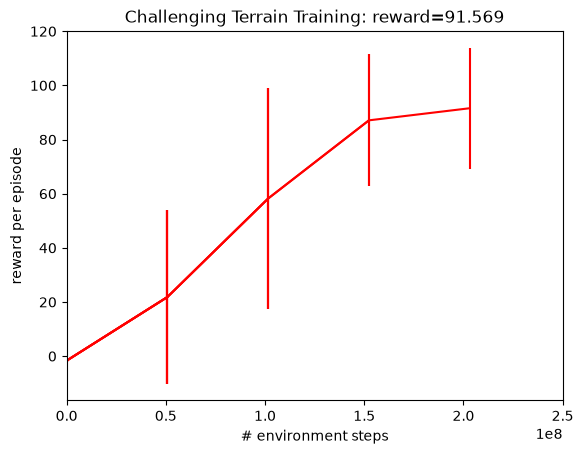

100%|██████████| 80/80 [00:08<00:00,  9.00it/s]


This browser does not support the video tag.


Training completed. Final checkpoint: /home/deployable/rl/eai2026_lab1_rl/artifacts/notebook_checkpoints/20260828_171756/final/params
Keyboard control: python remote_control.py --checkpoint artifacts/notebook_checkpoints/20260828_171756/final/params


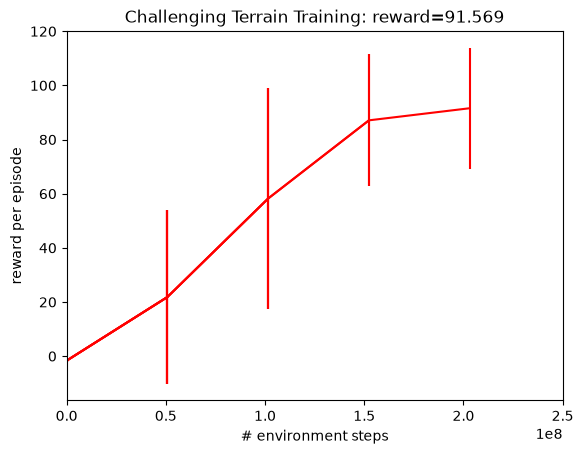

In [18]:
print("Starting training on challenging terrain...")
make_policy, params, _ = train_fn(environment=env,
                                  eval_env=PerceptiveJoystick(
                                      config=env_cfg,
                                      terrain_sample_constructor=terrain_sample_constructor),
                                  wrap_env_fn=wrapper.wrap_for_brax_training,
                                  compute_custom_ppo_loss_fn=ppo_losses.compute_ppo_loss
                                 )
latest_checkpoint = checkpoint_run_dir / 'final' / 'params'
latest_checkpoint.parent.mkdir(parents=True, exist_ok=True)
brax_model.save_params(str(latest_checkpoint), params)
save_perception_spec(latest_checkpoint, env)
print(f'Training completed. Final checkpoint: {latest_checkpoint.resolve()}')
print(f'Keyboard control: python remote_control.py --checkpoint {latest_checkpoint}')

## Evaluate the Trained Policy

Evaluate more than whether the robot eventually crosses an obstacle. Check command tracking, stability, gait quality, and whether its behavior changes appropriately before reaching a visible step. Use the terrain overlay to connect that behavior to the observations available to the policy.

In [ ]:
# Set up evaluation environment with challenging conditions
env_cfg = reward_config()
env_cfg.impl = "jax"  # Evaluation/video uses one world.
env_cfg.pert_config.enable = True
env_cfg.pert_config.velocity_kick = [2.0, 4.0]  # Add some perturbations
env_cfg.pert_config.kick_wait_times = [3.0, 10.0]
env_cfg.command_config.a = [1.2, 0.6, 2*jp.pi]  # Adjust command ranges

eval_env = PerceptiveJoystick(
    config=env_cfg, terrain_sample_constructor=terrain_sample_constructor
)
velocity_kick_range = [0.0, 0.0]  # Disable velocity kick for clearer evaluation
kick_duration_range = [0.05, 0.2]

jit_reset = jax.jit(eval_env.reset)
jit_step = jax.jit(eval_env.step)
jit_inference_fn = jax.jit(make_policy(params, deterministic=True))

print("Evaluating policy on challenging terrain...")
evaluate_policy(
    eval_env,
    jit_inference_fn,
    jit_step,
    jit_reset,
    env_cfg,
    eval_env,
    velocity_kick_range,
    kick_duration_range,
)